# Analyse Quantitative et Technique : Modélisation d'Indicateurs Avancés

**Auteur :** ISLEYEN Volkan
**Statut :** Étudiant L3 Économie & Gestion | Candidat Master Finance de Marché
**Sujet :** Programmation d'un module d'analyse technique complet (Tendance, Momentum, Volume)
**Stack Technique :** Pandas, NumPy, Matplotlib, Yfinance

---

## Contexte du Projet :

Dans le cadre de ma préparation pour le **Master Finance de Marché**, ce projet a pour objectif de développer un outil d'aide à la décision quantitatif. Plutôt que de se limiter à l'observation brute de l'évolution des prix, l'enjeu est de construire un script Python capable de décrypter la microstructure des mouvements de marché.

En m'appuyant sur les concepts fondamentaux de l'analyse technique, ce notebook modélise mathématiquement et visuellement les trois piliers de la dynamique d'un actif : sa **tendance**, sa **force (momentum)** et la **conviction des investisseurs (liquidité/volumes)**.

## Objectifs Quantitatifs et Financiers :

L'architecture du projet est conçue pour être modulaire et applicable à n'importe quel sous-jacent (ici illustré sur l'action Apple de 2021 à 2024). Les étapes clés sont les suivantes :

**1. Traitement des Séries Temporelles (Data Engineering)**
* Extraction des données OHLCV via l'API `yfinance`.
* Nettoyage des structures complexes (gestion des MultiIndex de l'API) et préparation des DataFrames pour le calcul vectoriel.

**2. Ingénierie des Indicateurs Techniques (Feature Engineering)**
Implémentation vectorisée (sans boucles) des algorithmes de marché classiques :
* **Oscillateurs de Momentum :** Calcul du **RSI** (Relative Strength Index) pour cartographier les zones de surachat et de survente.
* **Suivi de Tendance :** Modélisation du **MACD** (Moving Average Convergence Divergence) pour identifier les retournements de cycles.
* **Analyse des Flux de Capitaux (Volumes) :** Implémentation de l'**OBV** (On-Balance Volume), de la ligne **A/D** (Accumulation/Distribution) et du **CMF** (Chaikin Money Flow) pour évaluer la pression acheteuse/vendeuse réelle.

**3. Visualisation Stratégique et Détection de Signaux**
* Création de tableaux de bord graphiques superposant l'action des prix et les oscillateurs.
* Identification des **divergences** entre l'évolution des prix et les indicateurs de volume (signaux avancés de retournement de tendance).

## Méthodologie :

Ce projet met l'accent sur une programmation "propre" et performante en Python. L'utilisation conjointe de `pandas` et `numpy` permet des calculs vectorisés rapides, reproduisant l'approche utilisée dans les environnements de recherche quantitative en salle de marchés.

In [10]:
import yfinance as yf
import pandas as pd

In [11]:
apple = yf.download("AAPL", start = "2020-01-01", end = "2024-12-31")
apple.columns = apple.columns.droplevel("Ticker")
apple.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


In [15]:
clv = ((apple["Close"]-apple["Low"]) - (apple["High"]-apple["Close"])) / (apple["High"]-apple["Low"])

In [18]:
mfv = clv  * apple["Volume"]

In [19]:
cmf = mfv.rolling(window=20).sum() / apple["Volume"].rolling(window=20).sum()

In [20]:
apple["CMF"] = cmf

In [22]:
apple.tail()

Price,Close,High,Low,Open,Volume,CMF
Date,,,,,,
2024-12-23,253.883102,254.261028,252.072983,253.385819,40858800,0.401843
2024-12-24,256.797180,256.807105,253.902972,254.101897,23234700,0.379887
2024-12-26,257.612701,258.686851,256.230269,256.787224,27237100,0.364163
2024-12-27,254.201370,257.294489,251.685117,256.429191,42355300,0.349136
2024-12-30,250.829773,252.122713,249.387654,250.859609,35557500,0.325808


In [23]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Apple CMF')

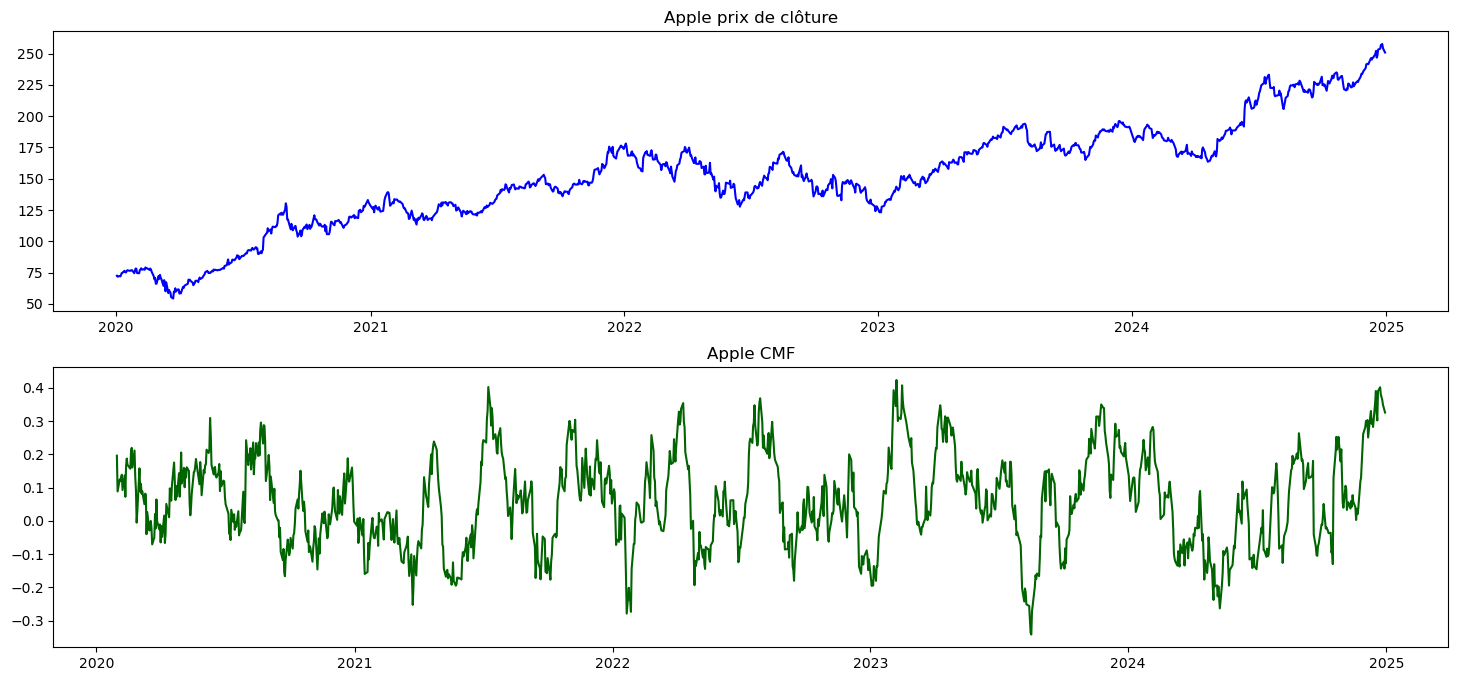

In [25]:
plt.figure(figsize=(18, 8))
plt.subplot(2, 1, 1)
plt.plot(apple["Close"], label='Clôture', color='blue')
plt.title("Apple prix de clôture")


plt.subplot(2, 1, 2)
plt.plot(apple["CMF"], label='CMF', color='darkgreen')
plt.title("Apple CMF")

###  Interprétation du CMF

| **CMF**       | **Signification**  |  
|------------------|------------------|
| CMF > 0    |Pression acheteuse --> tendance potentiellement haussière |
| CMF < 0           | Pression vendeuse --> tendance potentiellement baissière |
| CMF croissant ou décroissant     | Renforce la **direction** du marché |
| Divergence     |Si CMF diverge avec le prix --> possible retournement|